# Forecast trading strategy

---

Get the forecasted values of the trades in future given Monte Carlo simulation of underlying stock based on Heston process.

In [1]:
# Import system
import sys
sys.path.append('../')
# Get Python built-in packages
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
# Get the stockhealth packages
from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.analyzer import Trade, Transaction, TransactionType
from stockhealth.model import European as Bs
from stockhealth.model import VolatilitySmile as Vsmile
from stockhealth.model import _NUMBER_OF_CALENDAR_DAYS_PER_YEAR as _NCD
from stockhealth.training import Trends
from stockhealth.simulation import MonteCarlosWithHeston as Heston
from stockhealth.simulation import Derivative as OptionsFuture
from stockhealth.utilities.graph import plot as ProbabilityPlot

In [2]:
stock = Ts(ticker='SPY')
mdl = Trends(stock=stock)
sim_stock = Heston(trained_model=mdl, number_of_days=30)

In [3]:
sim_stock.solve()

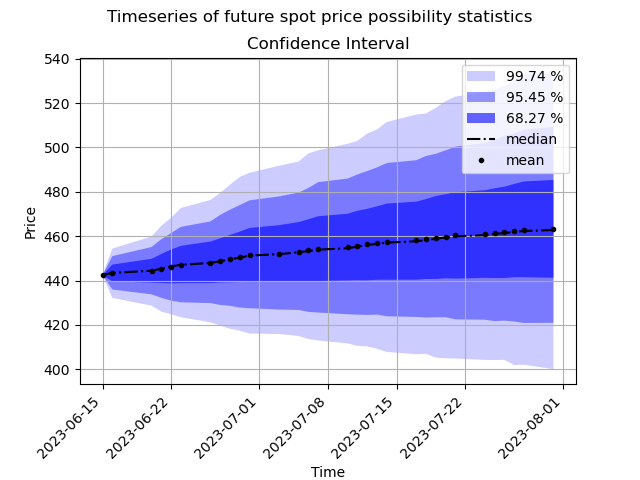

In [4]:
%matplotlib widget
f_s, a_s = sim_stock.plot(plot_volatility=False)

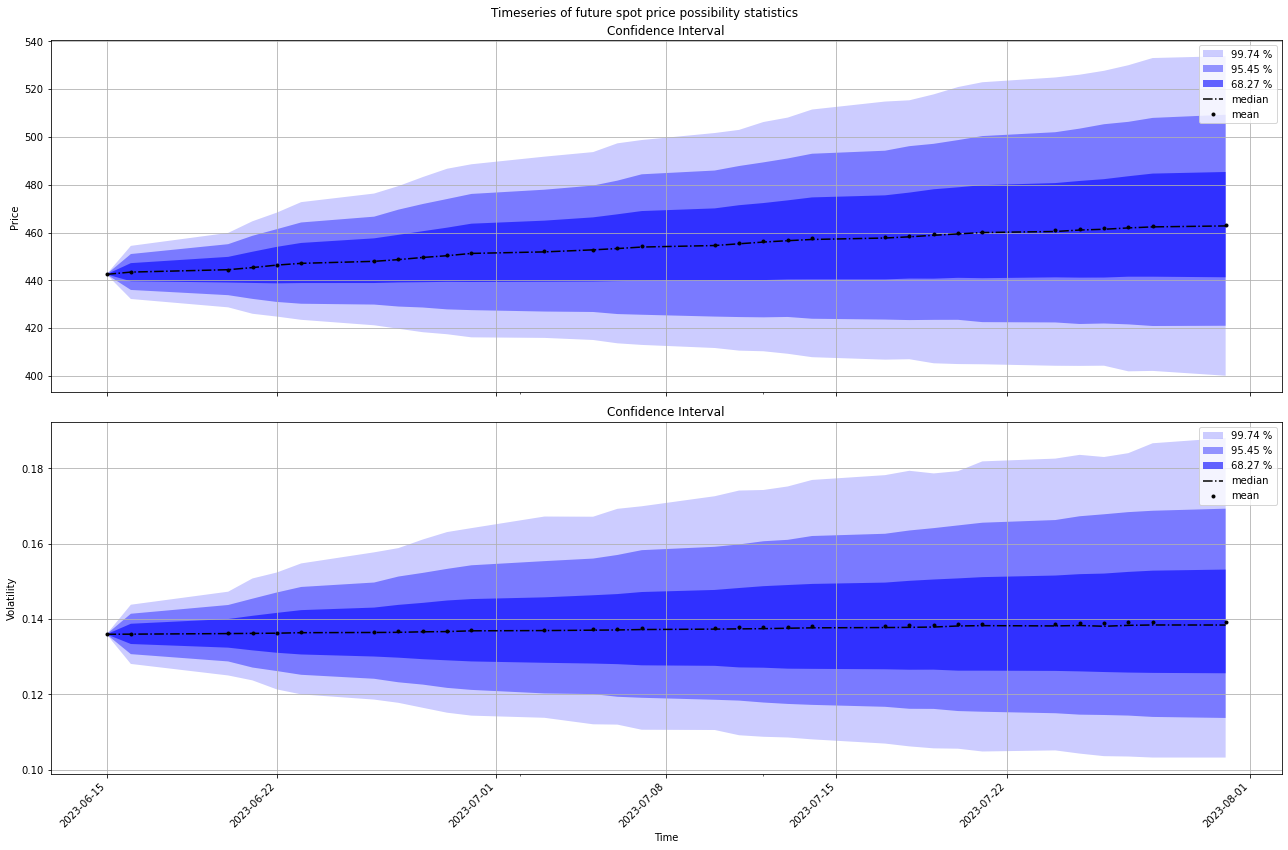

In [5]:
%matplotlib inline
f_pred = plt.figure('Prediction with uncertainty of stock future')
a_pred = f_pred.subplots(nrows=2, ncols=1, sharex=True)
_, _ = ProbabilityPlot(sim_stock.S, fig=f_pred, axs=a_pred[0])
_, _ = ProbabilityPlot(sim_stock.V, fig=f_pred, axs=a_pred[1])
a_pred[0].set_ylabel('Price')
a_pred[1].set_ylabel('Volatility')
f_pred.set_size_inches(w=18, h=12)
f_pred.tight_layout()

In [6]:
expiry_date = date(2023, 9, 29)
volatility_measure = 'impliedVolatility'
greek_on = True 
days_till_expiry = expiry_date - date.today()
call_chain = stock.options_chain__(
    expiry_date=expiry_date,
    type_of_transaction=TransactionType.call,
    interest_rate=0.07,
    greek_on=greek_on,
)
put_chain = stock.options_chain__(
    expiry_date=expiry_date,
    type_of_transaction=TransactionType.put,
    interest_rate=0.07,
    greek_on=greek_on,
)
call_smile = Vsmile(
    chain_data=call_chain,
    current_stock_price=stock.current__,
    volatility_measure=volatility_measure,
)
put_smile = Vsmile(
    chain_data=put_chain,
    current_stock_price=stock.current__,
    volatility_measure=volatility_measure,
)

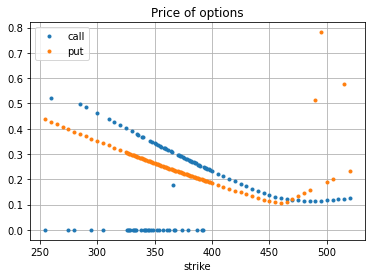

In [7]:
chain_property = 'impliedVolatility'
axs = call_chain[chain_property].plot(grid=True, label='call', style='.')
put_chain[chain_property].plot(grid=True, ax=axs, label='put', style='.')
axs.set_title('Price of options')
_ = axs.legend()

In [ ]:
option1 = Bs(
    S=mdl.history['latest close'],
    K=370,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)
option2 = Bs(
    S=mdl.history['latest close'],
    K=375,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)
option3 = Bs(
    S=mdl.history['latest close'],
    K=435,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)
option4 = Bs(
    S=mdl.history['latest close'],
    K=440,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)
option5 = Bs(
    S=mdl.history['latest close'],
    K=395,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)

In [8]:
option1 = Bs(
    S=mdl.history['latest close'],
    K=400,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)
option2 = Bs(
    S=mdl.history['latest close'],
    K=440,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.07,
    q=stock.dividend_yield,
)

In [ ]:
option5 = Bs(
    S=mdl.history['latest close'],
    K=100,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.05,
    q=stock.dividend_yield,
)

In [ ]:
option6 = Bs(
    S=mdl.history['latest close'],
    K=360,
    T=(days_till_expiry.days+1)/_NCD,
    r=0.06,
    q=stock.dividend_yield,
)

In [ ]:
sim_option1 = OptionsFuture(
    option=option1,
    simulation_of_underlying=sim_stock,
    put_price=put_chain['lastPrice'].loc[option1.K],
    vsmile=put_smile,
)
sim_option2 = OptionsFuture(
    option=option2,
    simulation_of_underlying=sim_stock,
    put_price=put_chain['lastPrice'].loc[option2.K],
    vsmile=put_smile,
)
sim_option3 = OptionsFuture(
    option=option3,
    simulation_of_underlying=sim_stock,
    call_price=call_chain['lastPrice'].loc[option3.K],
    vsmile=call_smile,
)
sim_option4 = OptionsFuture(
    option=option4,
    simulation_of_underlying=sim_stock,
    call_price=call_chain['lastPrice'].loc[option4.K],
    vsmile=call_smile,
)
sim_option5 = OptionsFuture(
    option=option5,
    simulation_of_underlying=sim_stock,
    put_price=put_chain['lastPrice'].loc[option5.K],
    vsmile=put_smile,
)

In [9]:
sim_option1 = OptionsFuture(
    option=option1,
    simulation_of_underlying=sim_stock,
    call_price=call_chain['lastPrice'].loc[option1.K],
    vsmile=call_smile,
)
sim_option2 = OptionsFuture(
    option=option2,
    simulation_of_underlying=sim_stock,
    put_price=put_chain['lastPrice'].loc[option2.K],
    vsmile=put_smile,
)

In [ ]:
sim_option5 = OptionsFuture(
    option=option5,
    simulation_of_underlying=sim_stock,
    put_price=put_chain['lastPrice'].loc[option5.K],
    vsmile=call_smile,
)

In [ ]:
sim_option6 = OptionsFuture(
    option=option6,
    simulation_of_underlying=sim_stock,
    call_price=call_chain['lastPrice'].loc[option6.K],
    vsmile=call_smile,
)

In [ ]:
sim_option1.solve()
sim_option2.solve()
sim_option3.solve()
sim_option4.solve()
sim_option5.solve()

In [10]:
sim_option1.solve()
sim_option2.solve()

In [ ]:
sim_option5.solve()

In [ ]:
sim_option6.solve()

In [ ]:
iron_condor = Trade(
    Transaction(simulation=sim_stock, amount=+0),
    Transaction(simulation=sim_option1, amount=+5),
    Transaction(simulation=sim_option2, amount=-5),
    Transaction(simulation=sim_option3, amount=-5),
    Transaction(simulation=sim_option4, amount=+5),
)
short_put = Trade(
    Transaction(simulation=sim_stock, amount=+0),
    Transaction(simulation=sim_option5, amount=-1),
)
trade = short_put 

In [ ]:
trade = Trade(
    Transaction(simulation=sim_stock, amount=+0),
    Transaction(simulation=sim_option5, amount=-1),
)

In [11]:
trade = Trade(
    Transaction(simulation=sim_stock, amount=+100),
    Transaction(simulation=sim_option1, amount=+0),
    Transaction(simulation=sim_option2, amount=+1),
)

In [ ]:
long_call = Trade(
    Transaction(simulation=sim_stock, amount=+0),
    Transaction(simulation=sim_option6, amount=+1),
)
trade = long_call

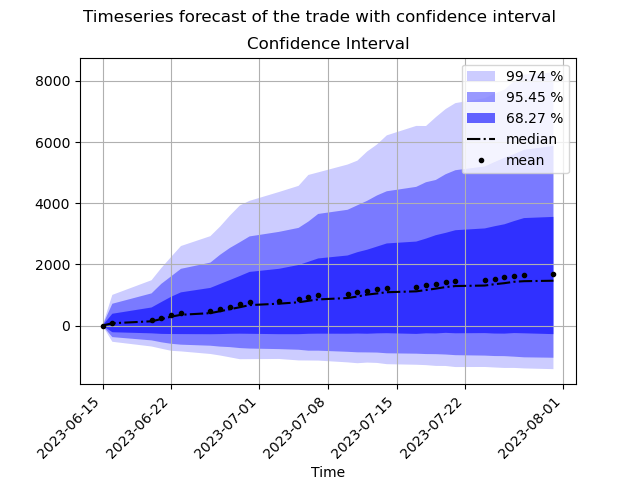

In [13]:
%matplotlib widget
f_trade, a_trade = ProbabilityPlot((trade.price - trade.price.iloc[0].mean()))
_ = f_trade.suptitle('Timeseries forecast of the trade with confidence interval')

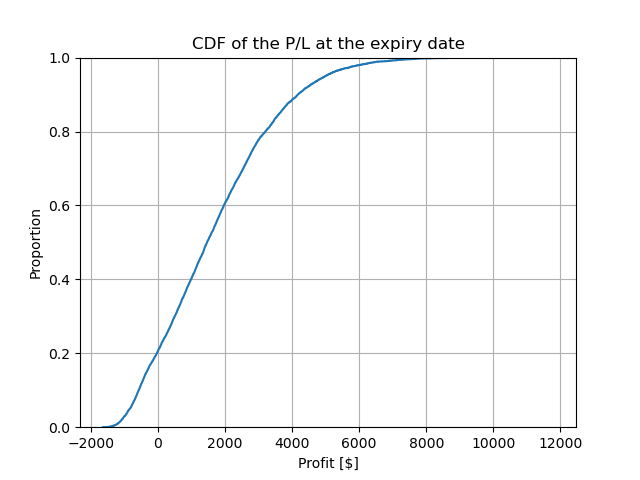

In [14]:
%matplotlib widget 
a_profit = sns.ecdfplot((trade.price - trade.price.iloc[0].mean()).iloc[-1])
a_profit.grid(True)
a_profit.set_xlabel('Profit [$]')
_ = a_profit.set_title('CDF of the P/L at the expiry date')

In [ ]:
a_pdf = ((trade.price - trade.price.iloc[0].mean()).iloc[-1]).plot.kde(grid=True)
a_pdf.set_xlabel('Profit [$]')
_ = a_pdf.set_title('PDF of the P/L at expiry')

In [12]:
expected_return = (trade.price.iloc[-1] - trade.price.iloc[0]).mean()
initial_investment = abs(trade.price.iloc[0].mean())
print('Expected return is $' + str(round(expected_return, 2)))
print('Expected ROI is ' + str(round(expected_return / (initial_investment) * 100, 2)) + '[%]')

Expected return is $1676.81
Expected ROI is 3.7[%]
